<a href="https://colab.research.google.com/github/jlosar/Julio-Losa-Anal.dados/blob/main/MVP_An%C3%A1lise_de_dados_e_boas_pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados de E-commerce Brasileiro
## Definição do Dataset
**Dataset utilizado no trabalho:** Brazilian E-Commerce Public Dataset by Olist

**Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

Os dados utilizados neste dataset são provenientes da Olist, uma plataforma de marketplace brasileira. O mesmo contém informação de aproximadamente 100 mil pedidos realizados entre os anos de 2016 e 2018 em diversos marketplaces brasileiros.

O dataset é formado por um conjunto de 8 tabelas conectadas por chaves únicas (IDS). Para este trabalho será consolidado 6 tabelas em uma única para que possamos ter uma melhor visão da jornada do pedido. As tabelas que iremos integrar são:

1. Pedidos
2. Itens
3. Clientes
4. Vendedores
5. Produtos
6. Geolocalização

A justificativa para utilização desse dataset é a quantidade de colunas temporais e obtenção das variáveis para construção de um modelo de aprendizado supervisionado que será proposto.


## Definição do problema

**Qual é a descrição do problema?**

Trabalhando no setor de varejo há alguns anos, entendo que um dos principais fatores que impactam a experiência do cliente é o mesmo receber uma mercadoria fora do prazo acordado, sendo assim, o objetivo da análise de dados em questão será desenvolver um modelo capaz de prever se um pedido chegará ao cliente após a data estimada de entrega informada no momento da compra.

**Este é um problema de aprendizado supervisionado ou não supervisionado?**

Este é um problema de aprendizado Supervisionado (Classificação Binária: "No Prazo" vs. "Atrasado").

**Que premissas ou hipóteses você tem sobre o problema?**
1.  A distância entre vendedor e comprador influencia diretamente o atraso.
2.  O peso e as dimensões do produto afetam o tempo de processamento logístico.
3.  Pedidos realizados em datas festivas (Black Friday) têm maior probabilidade de atraso.


**Que restrições ou condições foram impostas para selecionar os dados?**

Utilizaremos apenas pedidos com status "delivered" (entregues), pois precisamos das datas reais para validar o modelo.




In [66]:
# ==============================================================================================================
# Imports necessários
# ==============================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [67]:
# ==============================================================================================================
# Carregamento dos dados
# ==============================================================================================================

base_url = "https://raw.githubusercontent.com/jlosar/Julio-Losa-Anal.dados/main/Data/"

# Lista de arquivos principais a serem carregados
arquivos = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_customers_dataset.csv",
    "olist_sellers_dataset.csv",
    "olist_products_dataset.csv",
    "olist_geolocation_dataset.csv"
]

dfs = {}

for arquivo in arquivos:
    url = base_url + arquivo
    nome_df = arquivo.replace(".csv", "")
    try:
# Leitura dos dados

        dfs[nome_df] = pd.read_csv(url)
        print(f" {arquivo} carregado com sucesso!")
    except Exception as e:
        print(f"Erro ao carregar: {arquivo}")

 olist_orders_dataset.csv carregado com sucesso!
 olist_order_items_dataset.csv carregado com sucesso!
 olist_customers_dataset.csv carregado com sucesso!
 olist_sellers_dataset.csv carregado com sucesso!
 olist_products_dataset.csv carregado com sucesso!
 olist_geolocation_dataset.csv carregado com sucesso!


# União dos Dados e tratamento inicial de datas

## União dos dados (joins)

Essa parte do código foi necessária, pois o dataset escolhido é relacional, para fazermos a previsão de atraso precisamos correlacionar informações de todas as tabelas e essa parte do código nos permite isso. Assim, a consolidação das tabelas via Joins permitiu a criação de um Dataset Mestre, possibilitando a análise de várias óticas (logistica, geografica e fisica dos produtos)

## Tratamento inicial de datas

Dificuldade superada no trabalho: Quando o Python lê um arquivo CSV, ele entende que as datas são apenas textos comuns (strings) e para operar com datas eu preciso transformar isso em objetos datetime para fazer cálculos aritméticos. Sem essa conversão eu não conseguiria saber se um pedido atrasou ou não, pois preciso subtrair a data de entrega real da data de entrega estimada, identificando, com isso, como foi a performance logística.

## Leitura das primeiras linhas do Dataset

Foi pego um recorte de 5 linhas do dataset depois da consolidação para que pudessemos extrair observações e orietações para os próximos passos do pré processamento.



*   **Identificadores:** order_id, customer_id e product_id são alfanuméricos sendo assim devem ser tratados como identificadores únicos.
*   **Granularidade ao Nível de Item:** A presença da coluna order_item_id revela que a estrutura do dataset está no nível de item do pedido e não apenas por pedido único. Isso explica o shape de mais de 112 mil linhas, indicando que pedidos com múltiplos itens geram múltiplas instâncias, o que exigirá atenção para evitar duplicidade de pesos e fretes na análise agregada.
*   **Janela de Oportunidade Logística:** A visualização direta das colunas order_purchase_timestamp, order_delivered_customer_date e order_estimated_delivery_date mostra que o intervalo entre a compra e a entrega real varia significativamente
*   **Diversidade de Categorias e Dimensões:** Já nas primeiras linhas, percebemos produtos de categorias distintas (utilidades_domesticas, perfumaria, pet_shop), com pesos variando de 250g a 500g e dimensões diversas. Essa heterogeneidade é positiva, pois permite que o modelo aprenda se categorias específicas ou volumes maiores possuem maior correlação com gargalos logísticos.
*   **Consistência Geográfica:** Observa-se que a coluna seller_state apresenta vendedores de diferentes UFs (SP, MG). O fato de termos compradores e vendedores em polos distintos valida a nossa premissa de que o "venda_externa" (distância interestadual) será um forte candidato a feature de alta importância.








In [68]:
# ==============================================================================================================
# UNIÃO DOS DADOS (JOINS)
# ==============================================================================================================

# Unindo Pedidos com Itens
df = pd.merge(dfs['olist_orders_dataset'], dfs['olist_order_items_dataset'], on='order_id', how='inner')

# Unindo com Clientes (para localização do comprador)
df = pd.merge(df, dfs['olist_customers_dataset'], on='customer_id', how='inner')

# Unindo com Vendedores (para localização do vendedor)
df = pd.merge(df, dfs['olist_sellers_dataset'], on='seller_id', how='inner')

# Unindo com Produtos (para características físicas)
df = pd.merge(df, dfs['olist_products_dataset'], on='product_id', how='inner')

# ==============================================================================================================
# TRATAMENTO INICIAL DE DATAS
# ==============================================================================================================

# Converter colunas de data para o formato datetime
colunas_datas = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in colunas_datas:
    df[col] = pd.to_datetime(df[col])

print(f"Dataset mestre criado! Shape: {df.shape}")
df.head()

Dataset mestre criado! Shape: (112650, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,belo horizonte,SP,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,guariba,SP,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,belo horizonte,MG,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,mogi das cruzes,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


# Definição dos Atributos

Para garantir a clareza da análise e o cumprimento das premissas de boas práticas de documentação, foi definido o Dicionário de Dados. Esta etapa é crucial para alinhar o entendimento sobre quais variáveis atuarão como preditoras e qual será a nossa variável resposta, além de facilitar a interpretação dos resultados estatísticos que serão apresentados na sequência.

In [69]:
# ==============================================================================================================
# DEFINIÇÃO DOS ATRIBUTOS (Dicionário de Dados)
# ==============================================================================================================

# Criando um dicionário para facilitar a descrição no relatório
definicoes = {
    "order_id": "Identificador único de cada pedido.",
    "customer_id": "Chave de ligação com a tabela de clientes (cada pedido tem um customer_id único).",
    "order_status": "Status do pedido (ex: delivered, shipped). Filtramos apenas 'delivered'.",
    "order_purchase_timestamp": "Data e hora em que a compra foi realizada pelo cliente.",
    "order_delivered_customer_date": "Data real em que o cliente recebeu o produto (usada para calcular o target).",
    "order_estimated_delivery_date": "Data de entrega prevista informada no momento da compra.",
    "price": "Preço de venda do produto.",
    "freight_value": "Valor do frete pago pelo cliente.",
    "product_id": "Identificador único do produto.",
    "product_weight_g": "Peso do produto em gramas (variável física importante para logística).",
    "customer_state": "Estado (UF) de residência do comprador.",
    "seller_state": "Estado (UF) onde o vendedor está localizado.",
    "atrasado (Target)": "Variável alvo: 1 se a entrega real > estimada, 0 se foi no prazo."
}

# Exibindo de forma organizada
print(f"{'Atributo':<30} | {'Descrição':<60}")
print("-" * 95)
for coluna, descricao in definicoes.items():
    if coluna in df.columns or coluna == "atrasado (Target)":
        print(f"{coluna:<30} | {descricao:<60}")

Atributo                       | Descrição                                                   
-----------------------------------------------------------------------------------------------
order_id                       | Identificador único de cada pedido.                         
customer_id                    | Chave de ligação com a tabela de clientes (cada pedido tem um customer_id único).
order_status                   | Status do pedido (ex: delivered, shipped). Filtramos apenas 'delivered'.
order_purchase_timestamp       | Data e hora em que a compra foi realizada pelo cliente.     
order_delivered_customer_date  | Data real em que o cliente recebeu o produto (usada para calcular o target).
order_estimated_delivery_date  | Data de entrega prevista informada no momento da compra.    
price                          | Preço de venda do produto.                                  
freight_value                  | Valor do frete pago pelo cliente.                           
product_i

# Análise Descritiva Inicial e a Verificação da Integridade dos Dados

Esta etapa teve como objetivo realizar um diagnóstico inicial das variáveis numéricas e validar a tipagem dos dados.

**1. Estatísticas Descritivas das Variáveis Numérica:**

A tabela gerada pelo método .describe() revela o comportamento central e a dispersão dos principais atributos financeiros e físicos:


*   Price (Preço): Observa-se uma média de aproximadamente 120,65, enquanto a mediana de 74,99 e a moda de 59,90 revelam que a grande maioria das transações ocorre em valores significativamente menores. O desvio padrão elevado (183,63) e a grande distância entre a mediana e o valor máximo (6.735,00) indicam a presença de outliers (valores extremos), sugerindo que o catálogo é composto majoritariamente por produtos de baixo valor, com poucos itens de luxo ou industriais.

*   freight_value (Frete): O frete médio é de 19,99, mas a moda de 15,10 indica o custo logístico mais frequente no ecossistema. A disparidade entre a média e o máximo (409,68) reforça a influência da longa distância logística no Brasil e de produtos volumosos, fatores críticos para a previsão de atrasos.

*   product_weight_g (Peso): Apresenta uma média de 2.093g, mas a mediana de 700g mostra que metade dos produtos entregues são itens leves. Um ponto de atenção técnica é a existência de 18 valores ausentes, que precisarão ser tratados na etapa de pré-processamento.


**2. Verificação de Tipos de Dados (dtypes)**

A listagem dos tipos de dados confirma que a operação de conversão realizada anteriormente foi bem-sucedida:


*   Campos Temporais: Atributos como order_purchase_timestamp e order_delivered_customer_date estão corretamente tipados como datetime64[ns]. Isso é vital, pois permite que o sistema realize cálculos de subtração para definir a variável alvo (atraso).

*   Variáveis Categóricas e Numéricas: Os identificadores (IDs) e localizações estão como object (strings), enquanto valores monetários e físicos estão como float64 ou int64, adequados para cálculos estatísticos.


**3. Por que estes resultados são importantes para o projeto?**


*   Identificação de Desafios: A análise revelou que o dataset é "ruidoso" (com muitos outliers e alguns valores nulos), o que justifica a necessidade de transformações matemáticas, como o logaritmo, para estabilizar os dados antes do treinamento.

*   Validação de Hipóteses: Os dados confirmam que variáveis como frete e peso possuem grande variabilidade, o que sustenta a hipótese de que são bons preditores para modelos de logística.

*   Segurança Técnica: Garantir que não há nulos nas colunas de preço e frete, e que as datas são reconhecidas como tempo, assegura que as visualizações de distribuição (como os gráficos de pizza e barras gerados posteriormente) sejam precisas e representativas da realidade da Olist.



In [70]:
# ==============================================================================================================
# ANÁLISE DE DADOS: Estatísticas Descritivas e Estrutura do Dataset
# ==============================================================================================================

# 1. Identificando a estrutura do Dataset (Instâncias e Atributos)
n_instancias, n_atributos = df.shape
print(f"Estrutura do Dataset:")
print(f"O dataset consolidado possui {n_instancias} instâncias (pedidos/itens) e {n_atributos} atributos (colunas).\n")

# 2. Resumo Estatístico Conforme Checklist
colunas_analise = ['price', 'freight_value', 'product_weight_g']

# Criando o DataFrame de resumo com describe
resumo = df[colunas_analise].describe().T

# Adicionando os itens solicitados pelo checklist que não vêm no .describe()
resumo['mediana'] = df[colunas_analise].median()
resumo['moda'] = [df[col].mode()[0] for col in colunas_analise]
resumo['valores_ausentes'] = df[colunas_analise].isnull().sum()

# Renomeando as colunas do describe para Português
resumo = resumo.rename(columns={
    'mean': 'média',
    'std': 'desvio-padrão',
    'min': 'mínimo',
    'max': 'máximo',
    'count': 'contagem'
})

# Reorganizando a ordem das colunas para seguir o checklist
ordem_checklist = ['mínimo', 'máximo', 'mediana', 'moda', 'média', 'desvio-padrão', 'valores_ausentes']
resumo = resumo[ordem_checklist]

print("Resumo Estatístico dos Atributos Numéricos:")
display(resumo)

Estrutura do Dataset:
O dataset consolidado possui 112650 instâncias (pedidos/itens) e 29 atributos (colunas).

Resumo Estatístico dos Atributos Numéricos:


,mínimo,máximo,mediana,moda,média,desvio-padrão,valores_ausentes
price,0.85,6735.00,74.99,59.9,120.653739,183.633928,0
freight_value,0.00,409.68,16.26,15.1,19.990320,15.806405,0
product_weight_g,0.00,40425.00,700.00,200.0,2093.672047,3751.596884,18


## Análise da Variável Alvo e Distribuição Inicial dos Dados

Com base na definição do problema, foi criada a variável alvo (target) denominada atrasado, que classifica cada pedido em duas categorias: entregas realizadas dentro do prazo (0) e entregas realizadas após a data estimada (1). Essa variável é fundamental para estruturar o problema como uma tarefa de classificação binária e permitir a análise do comportamento logístico dos pedidos.

A partir dessa definição, foram realizadas visualizações iniciais com o objetivo de compreender a distribuição das classes e identificar possíveis padrões associados ao atraso das entregas. Em primeiro lugar, analisou-se a proporção de pedidos no prazo versus atrasados, o que permite avaliar o nível de balanceamento da variável alvo.

Em seguida, foi investigada a variação da taxa de atraso por estado do cliente, buscando identificar possíveis diferenças regionais no desempenho logístico. Por fim, foi analisada a distribuição do valor do frete, uma variável diretamente relacionada ao custo e à complexidade da operação de entrega, com o intuito de verificar sua dispersão e possíveis indícios de relação com atrasos.

Essas análises iniciais fornecem uma visão geral do comportamento da variável alvo e das principais variáveis explicativas, permitindo identificar padrões relevantes e direcionar as etapas seguintes de exploração e pré-processamento dos dados.

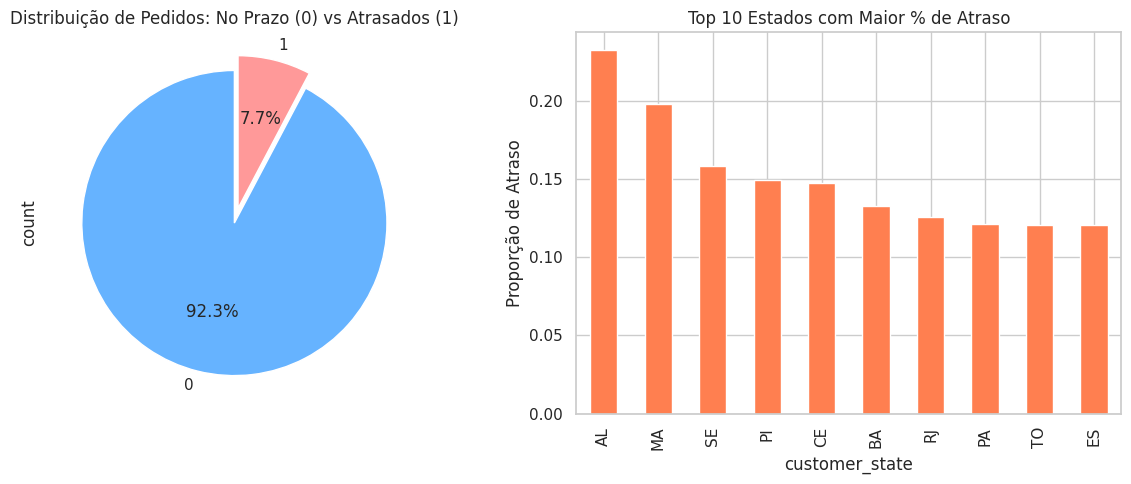

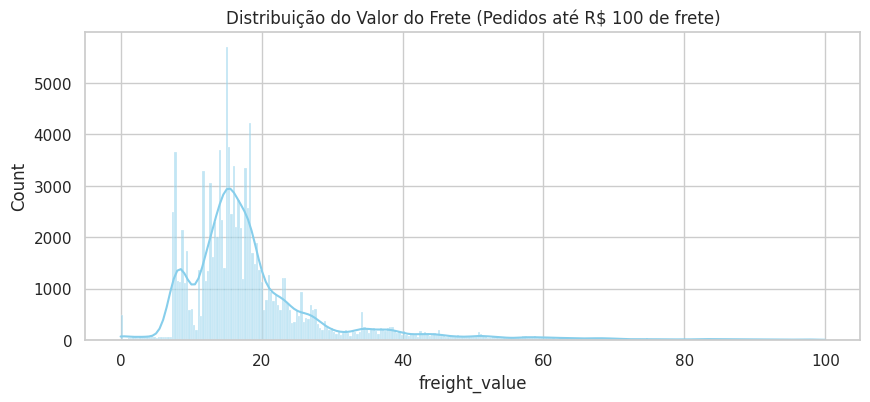

In [71]:
# 1. CRIANDO A VARIÁVEL ALVO (TARGET)
# Se a entrega real foi depois da estimada, atribuímos 1 (Atraso), senão 0 (No prazo)
df['atrasado'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)

# 2. VISUALIZAÇÃO DA DISTRIBUIÇÃO DAS CLASSES
plt.figure(figsize=(12, 5))

# Gráfico de Pizza (Frequência das Classes)
plt.subplot(1, 2, 1)
df['atrasado'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1))
plt.title('Distribuição de Pedidos: No Prazo (0) vs Atrasados (1)')

# Gráfico de Barras por Estado (Top 10 Estados com mais atrasos em %)
plt.subplot(1, 2, 2)
atraso_por_estado = df.groupby('customer_state')['atrasado'].mean().sort_values(ascending=False).head(10)
atraso_por_estado.plot(kind='bar', color='coral')
plt.title('Top 10 Estados com Maior % de Atraso')
plt.ylabel('Proporção de Atraso')

plt.tight_layout()
plt.show()

# 3. DISTRIBUIÇÃO DO PREÇO DO FRETE (Histograma)
plt.figure(figsize=(10, 4))
sns.histplot(df[df['freight_value'] < 100]['freight_value'], kde=True, color='skyblue')
plt.title('Distribuição do Valor do Frete (Pedidos até R$ 100 de frete)')
plt.show()

## Análise Exploratória Avançada: Distribuições, Outliers e Relações entre Variáveis

Com o objetivo de aprofundar a compreensão do comportamento das principais variáveis do dataset, foram realizadas análises exploratórias adicionais focadas na distribuição dos dados, identificação de outliers e investigação de possíveis relações entre atributos relevantes para o problema de atraso logístico.

Inicialmente, foi analisada a distribuição da variável de preço, com foco nos valores mais representativos da base, a fim de compreender a concentração das transações e reduzir o efeito visual de valores extremos. Em seguida, foi conduzida uma análise combinada entre o valor do frete e o status de atraso, utilizando boxplots para verificar possíveis diferenças no comportamento logístico entre pedidos entregues no prazo e pedidos atrasados.

Além disso, foi realizada a identificação de outliers na variável de peso dos produtos, permitindo observar a existência de itens com características físicas significativamente distintas, que podem impactar diretamente a complexidade da entrega. Por fim, foi construído um mapa de correlação entre as principais variáveis numéricas, com o intuito de avaliar a existência de relações lineares que possam auxiliar na compreensão dos fatores associados ao atraso.

Essas análises complementares permitem uma visão mais detalhada da estrutura dos dados, auxiliando na validação das hipóteses iniciais e na definição das estratégias de pré-processamento a serem aplicadas na etapa seguinte.

## Interpretação das Visualizações Exploratórias

As análises gráficas realizadas permitem extrair insights importantes sobre a estrutura e o comportamento do dataset. A distribuição de preços evidencia uma forte concentração em produtos de baixo valor, acompanhada de uma cauda longa que indica a presença de itens com valores significativamente mais elevados. Esse padrão reforça a existência de assimetria nos dados, justificando a aplicação de transformações como o logaritmo para estabilizar a distribuição.

A análise combinada entre o valor do frete e o status de atraso sugere que pedidos atrasados tendem a apresentar, em média, fretes ligeiramente mais elevados, além de maior variabilidade. Embora essa diferença não seja suficientemente forte para indicar uma relação determinística, ela sugere que o custo logístico pode estar associado à complexidade da entrega, funcionando como um possível fator explicativo do atraso.

A identificação de outliers na variável de peso confirma a alta heterogeneidade do dataset, com a presença de produtos muito leves e outros extremamente pesados. Esse comportamento indica que as características físicas dos produtos podem impactar o processo logístico e, consequentemente, o desempenho das entregas.

Por fim, o mapa de correlação revela relações moderadas entre variáveis como peso e frete, o que está alinhado com a lógica de negócio. No entanto, observa-se que a variável de atraso apresenta baixa correlação linear com as demais, indicando que o fenômeno analisado não é explicado por uma única variável isolada, mas possivelmente por interações mais complexas entre múltiplos fatores.

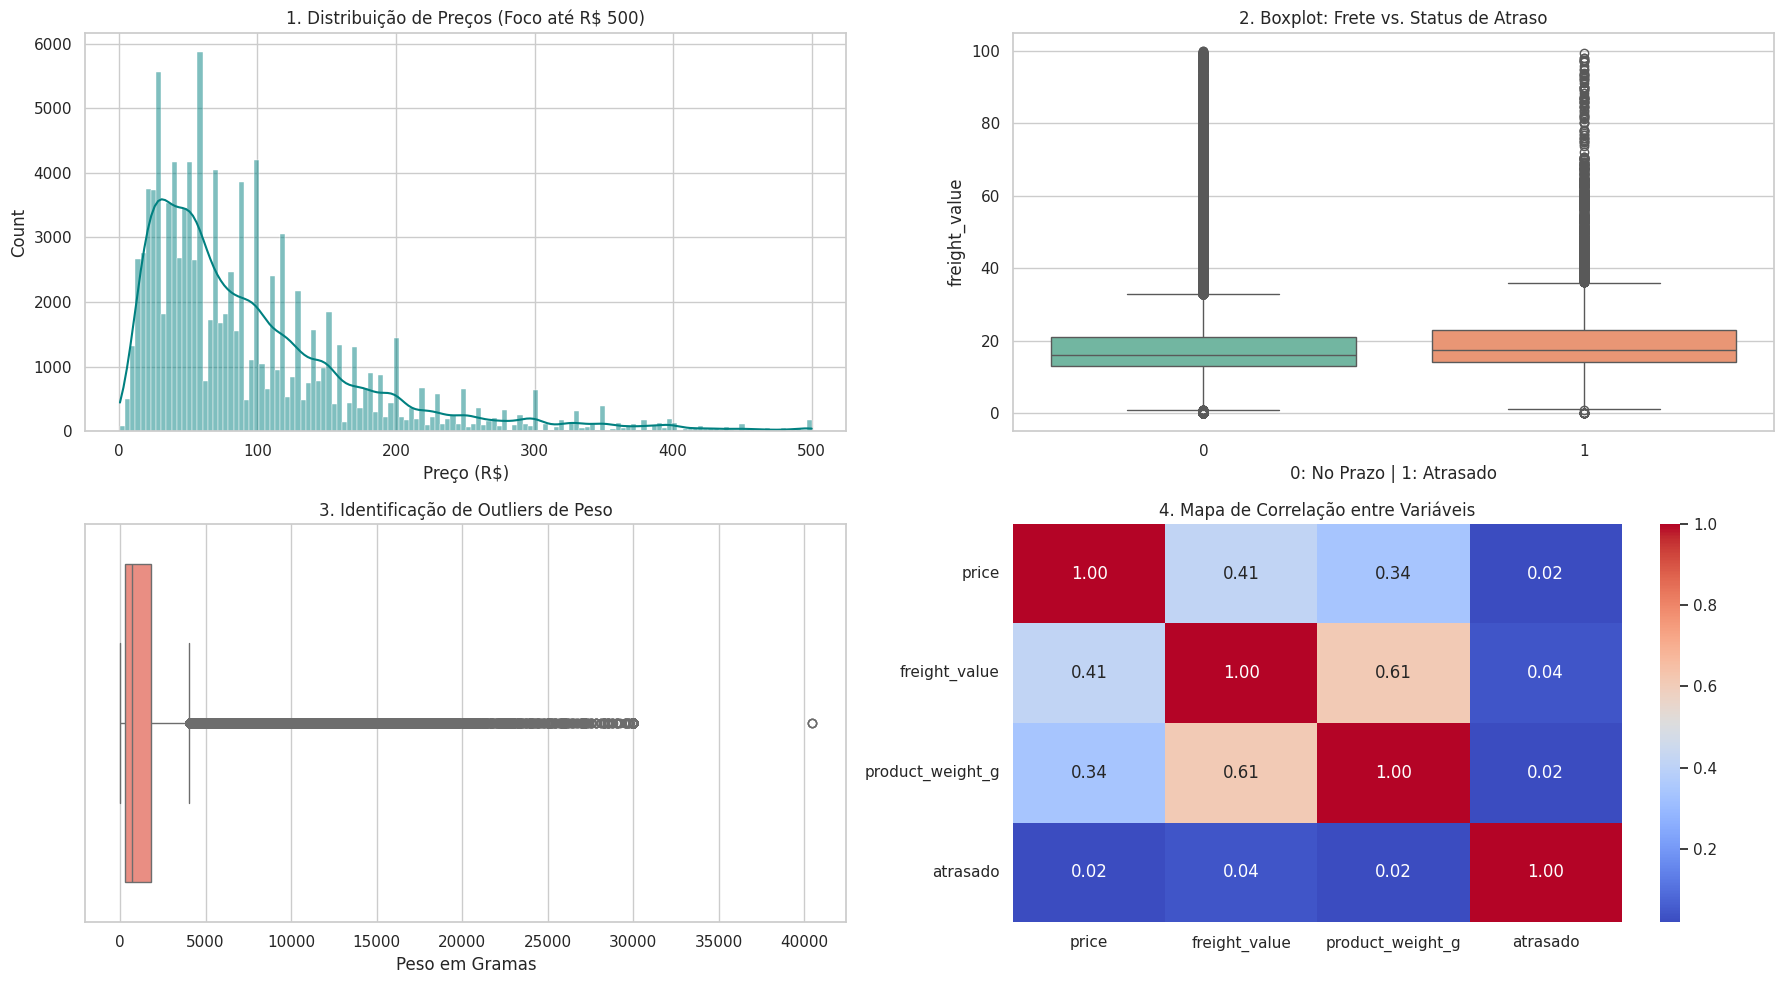

In [72]:
# ==============================================================================================================
# VISUALIZAÇÕES: DISTRIBUIÇÕES E OUTLIERS (INDIVIDUAIS E COMBINADAS)
# ==============================================================================================================

# Configurando o estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 10))

# 1. Distribuição de Preços (Histograma Individual)
plt.subplot(2, 2, 1)
sns.histplot(df[df['price'] < 500]['price'], kde=True, color='teal')
plt.title('1. Distribuição de Preços (Foco até R$ 500)')
plt.xlabel('Preço (R$)')

# 2. Boxplot de Frete vs. Atraso (Análise Combinada)
plt.subplot(2, 2, 2)
sns.boxplot(
    x='atrasado',
    y='freight_value',
    hue='atrasado',
    data=df[df['freight_value'] < 100],
    palette='Set2',
    legend=False
)
plt.title('2. Boxplot: Frete vs. Status de Atraso')
plt.xlabel('0: No Prazo | 1: Atrasado')

# 3. Boxplot de Peso (Identificação de Outliers Individuais)
plt.subplot(2, 2, 3)
sns.boxplot(x=df['product_weight_g'], color='salmon')
plt.title('3. Identificação de Outliers de Peso')
plt.xlabel('Peso em Gramas')

# 4. Heatmap de Correlação (Relação entre Atributos)
plt.subplot(2, 2, 4)
colunas_corr = ['price', 'freight_value', 'product_weight_g', 'atrasado']
sns.heatmap(df[colunas_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('4. Mapa de Correlação entre Variáveis')

plt.tight_layout()
plt.show()

## Análise Temporal: Proporção de Atrasos e Volume de Pedidos ao Longo do Tempo

Com o objetivo de investigar possíveis padrões temporais no comportamento dos atrasos logísticos, foi realizada uma análise agregada por mês de compra. Essa abordagem permite avaliar não apenas a evolução da proporção de pedidos atrasados ao longo do tempo, mas também considerar o volume de pedidos em cada período, evitando interpretações enviesadas por meses com baixa representatividade.

Para isso, foram calculadas duas métricas principais: (i) a proporção de pedidos atrasados em cada mês e (ii) o volume total de pedidos realizados no mesmo período. A visualização conjunta dessas duas dimensões possibilita identificar se variações na taxa de atraso estão associadas a períodos de maior demanda, como eventos sazonais, ou se ocorrem de forma independente do volume transacional.

## Interpretação da Análise Temporal

A análise temporal revela um crescimento consistente no volume de pedidos ao longo do período analisado, especialmente entre 2017 e 2018, indicando expansão da operação do marketplace. Paralelamente, observa-se que a proporção de atrasos apresenta comportamento volátil ao longo do tempo, sem uma tendência clara de crescimento ou redução.

Em determinados períodos, como no final de 2017 e início de 2018, é possível identificar picos na taxa de atraso, que podem estar associados a eventos sazonais de alta demanda, como promoções e datas comerciais relevantes. No entanto, a relação entre volume de pedidos e atraso não se mostra perfeitamente linear, uma vez que há períodos de alto volume com níveis moderados de atraso.

Esse comportamento sugere que o atraso logístico não é determinado exclusivamente pelo volume de pedidos, mas sim por uma combinação de fatores, possivelmente incluindo características geográficas, físicas dos produtos e eficiência operacional. Adicionalmente, observa-se que períodos com baixo volume podem apresentar proporções de atraso distorcidas, o que reforça a importância de analisar conjuntamente volume e proporção para uma interpretação mais precisa.

OBS: Observa-se um pico de atrasos no início da série (setembro de 2016), porém esse período apresenta baixo volume de pedidos. Assim, pequenas variações geram grandes oscilações percentuais, não representando um padrão real, mas sim uma limitação no início da base de dados.

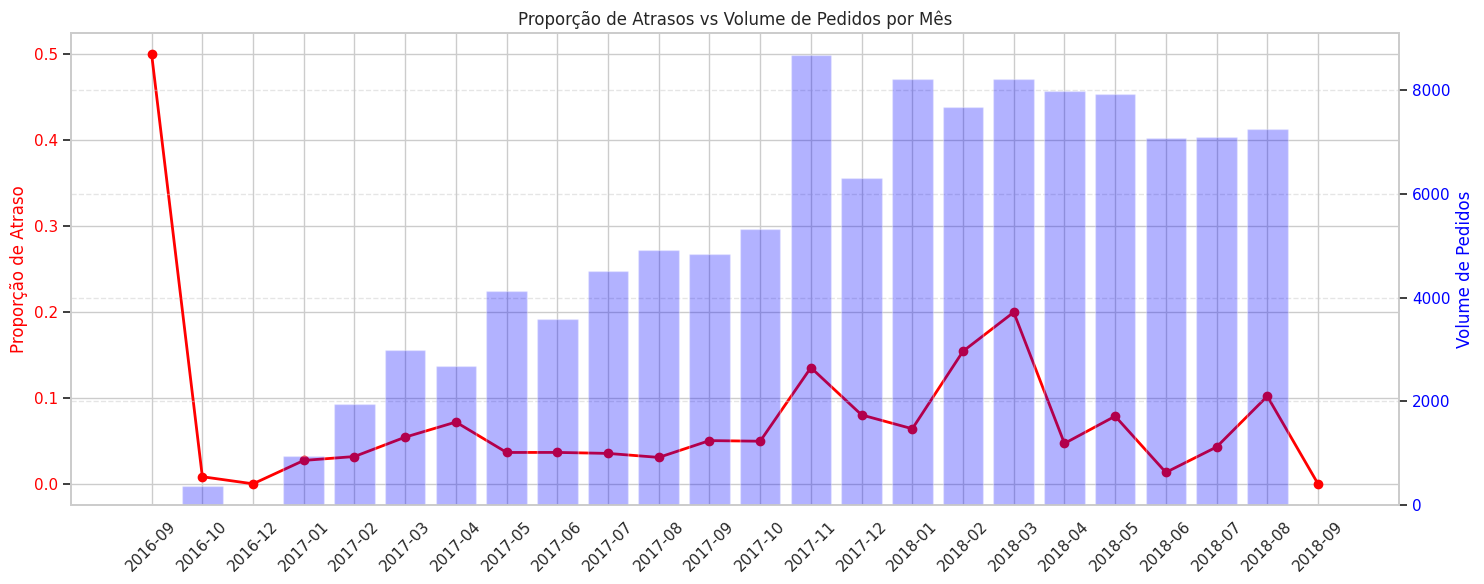

In [73]:
# Criando coluna de Mês da Compra (mantendo ordenação correta)
df['month_purchase'] = df['order_purchase_timestamp'].dt.to_period('M')

# Agrupando dados
agg_month = df.groupby('month_purchase').agg(
    proporcao_atraso=('atrasado', 'mean'),
    volume_pedidos=('order_id', 'count')
).reset_index()

# Convertendo para string apenas para visualização
agg_month['month_purchase'] = agg_month['month_purchase'].astype(str)

# Criando figura
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linha: Proporção de atraso ---
ax1.plot(agg_month['month_purchase'], agg_month['proporcao_atraso'],
         color='red', marker='o', linewidth=2, label='Proporção de Atraso')

ax1.set_ylabel('Proporção de Atraso', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax1.set_xticks(range(len(agg_month)))
ax1.set_xticklabels(agg_month['month_purchase'], rotation=45)

# --- Barra: Volume de pedidos ---
ax2 = ax1.twinx()
ax2.bar(range(len(agg_month)), agg_month['volume_pedidos'],
        alpha=0.3, color='blue', label='Volume de Pedidos')

ax2.set_ylabel('Volume de Pedidos', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Título
plt.title('Proporção de Atrasos vs Volume de Pedidos por Mês')

# Melhorar layout
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Análise por Categoria de Produto: Volume de Pedidos e Desempenho Logístico

Para entender melhor como o desempenho logístico varia entre os produtos, foi feita uma análise comparando o volume de pedidos com a taxa de atraso por categoria.

Para evitar distorções causadas por categorias com poucos pedidos, o foco ficou nas 10 categorias com maior volume. Para cada uma delas, foram analisadas duas métricas principais: o total de pedidos e a proporção de entregas com atraso.

Essa análise ajuda a identificar não só quais categorias são mais relevantes para o negócio em termos de volume, mas também como cada uma performa logisticamente em relação à média geral.

## Interpretação da Análise por Categoria

Os resultados mostram que o volume de pedidos está concentrado em poucas categorias, com destaque para segmentos como cama, mesa e banho, beleza e saúde, e esporte e lazer. Isso indica que grande parte da operação do marketplace está ligada a esses tipos de produto.

Quando olhamos para a taxa de atraso, algumas categorias se destacam negativamente, apresentando níveis acima da média. É o caso de beleza e saúde e cama, mesa e banho, que além de terem alto volume, também apresentam mais atrasos — o que pode indicar gargalos na operação.

Por outro lado, existem categorias com desempenho melhor, com taxas de atraso abaixo da média, mostrando que o processo logístico não se comporta da mesma forma para todos os produtos.

De forma geral, os resultados sugerem que características como peso, tamanho e complexidade de transporte podem influenciar diretamente nos atrasos, o que reforça as hipóteses iniciais do estudo e indica que diferentes categorias podem precisar de estratégias logísticas específicas.

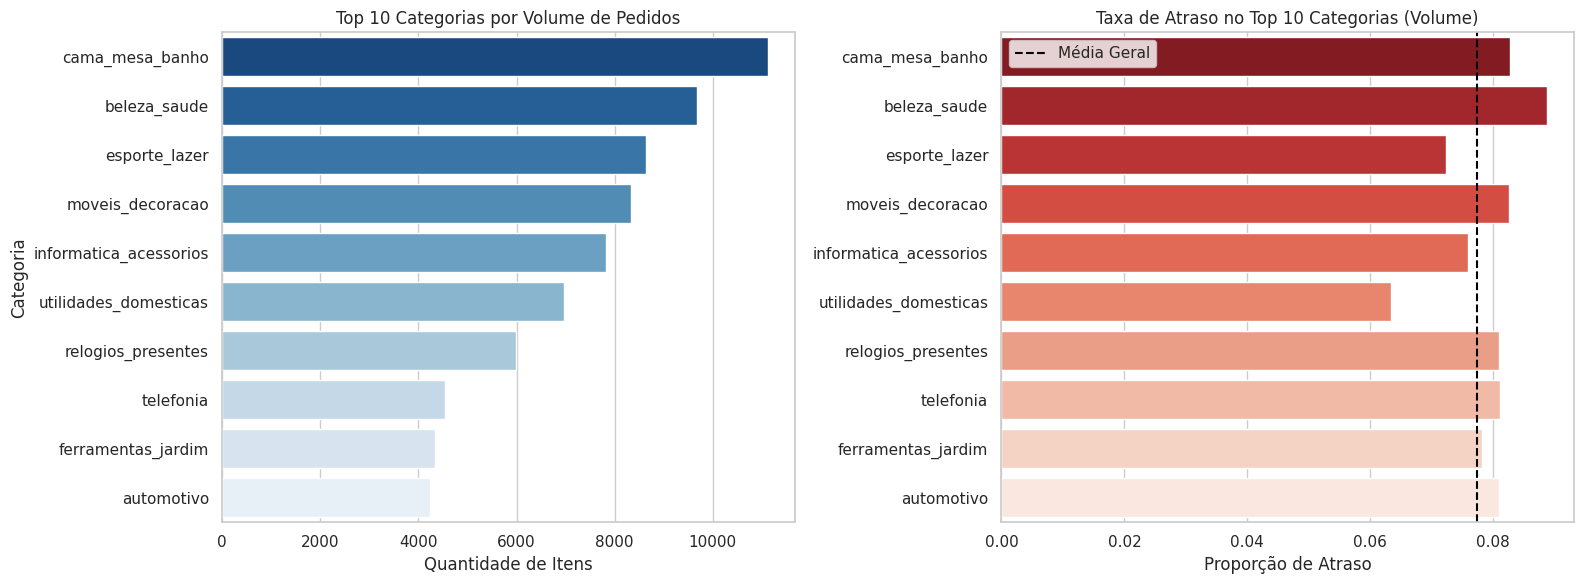

In [74]:
# ==============================================================================================================
# ANÁLISE DE CATEGORIAS: VOLUME VS. TAXA DE ATRASO (TOP 10)
# ==============================================================================================================

# 1. Calculando volume e taxa de atraso por categoria
cat_analysis = df.groupby('product_category_name').agg(
    total_pedidos=('atrasado', 'count'),
    taxa_atraso=('atrasado', 'mean')
).reset_index()

# 2. Filtrando as 10 categorias com maior volume de vendas para uma análise estatisticamente relevante
top_10_vol = cat_analysis.sort_values(by='total_pedidos', ascending=False).head(10)

# 3. Visualização
plt.figure(figsize=(16, 6))

# Gráfico de Barras: Volume de Pedidos
plt.subplot(1, 2, 1)
sns.barplot(
    data=top_10_vol,
    y='product_category_name',
    x='total_pedidos',
    hue='product_category_name',
    palette='Blues_r',
    legend=False
)
plt.title('Top 10 Categorias por Volume de Pedidos')
plt.xlabel('Quantidade de Itens')
plt.ylabel('Categoria')

# Gráfico de Barras: Taxa de Atraso
plt.subplot(1, 2, 2)
sns.barplot(
    data=top_10_vol,
    y='product_category_name',
    x='taxa_atraso',
    hue='product_category_name',
    palette='Reds_r',
    legend=False
)

# Adicionando uma linha vertical com a média geral de atraso para comparação
plt.axvline(df['atrasado'].mean(), color='black', linestyle='--', label='Média Geral')

plt.title('Taxa de Atraso no Top 10 Categorias (Volume)')
plt.xlabel('Proporção de Atraso')
plt.ylabel('')
plt.legend()

plt.tight_layout()
plt.show()

## Pré-processamento de Dados: Limpeza, Transformação e Preparação para Análise

Após a etapa de análise exploratória, foi realizado o pré-processamento dos dados com o objetivo de corrigir inconsistências, tratar valores faltantes e preparar o dataset para análises mais robustas.

Inicialmente, foi criada uma cópia do dataset original, garantindo a preservação dos dados brutos e permitindo a comparação entre diferentes versões ao longo do processo. Em seguida, foram aplicadas técnicas de tratamento de valores ausentes, transformação de variáveis e criação de novos atributos, com base nos insights obtidos na etapa exploratória.

Além disso, foram realizadas transformações matemáticas para reduzir a assimetria de variáveis numéricas e aplicada codificação de variáveis categóricas, permitindo sua utilização em análises quantitativas. Por fim, foi definida a variável alvo do problema, consolidando o dataset final que será utilizado nas etapas seguintes.

## Tratamento de Valores Faltantes

O tratamento de valores ausentes foi realizado de forma seletiva, considerando a relevância de cada variável para o problema analisado. Inicialmente, foram removidos os registros que não possuíam informação de data de entrega real, uma vez que esses dados são essenciais para a definição da variável alvo (atraso) e não poderiam ser inferidos de forma confiável.

Para a variável de peso dos produtos, que apresentava um número reduzido de valores ausentes, foi aplicada imputação pela mediana. Essa escolha se justifica pela presença de outliers na distribuição, tornando a mediana uma medida mais robusta em comparação à média.

As demais variáveis não passaram por tratamento de valores faltantes, uma vez que não impactam diretamente o objetivo da análise nesta etapa, evitando assim a introdução de vieses desnecessários no dataset.

## Resultados do Pré-processamento

Ao final do processo de pré-processamento, o dataset resultante apresentou um total de 60 variáveis, refletindo principalmente a aplicação de técnicas de codificação de variáveis categóricas, como o One-Hot Encoding. Essa expansão de atributos permite uma representação mais detalhada das informações, especialmente no que diz respeito à localização dos clientes.

Em relação à qualidade dos dados, ainda foram identificados valores ausentes no dataset final. Esse comportamento é esperado, uma vez que o tratamento de valores faltantes foi direcionado apenas às variáveis consideradas críticas para a análise, como a data de entrega e o peso dos produtos. Dessa forma, optou-se por não realizar imputações generalizadas em todas as variáveis, evitando a introdução de vieses artificiais.

De modo geral, o pré-processamento resultou em um dataset mais estruturado, com variáveis adequadamente tratadas e transformadas, mantendo a integridade das informações relevantes para o problema analisado.

In [75]:
# ==============================================================================================================
#  PRÉ-PROCESSAMENTO DE DADOS
# ==============================================================================================================

# Criando uma cópia para preservar o dataset original (Boa prática!)
df_proc = df.copy()

print("Iniciando Pré-processamento...")

# 1. TRATAMENTO DE VALORES FALTANTES (MISSING VALUES)
# Datas: Pedidos sem data de entrega real não podem ser usados para prever atraso.
df_proc = df_proc.dropna(subset=['order_delivered_customer_date'])

# Atributos do Produto: Foi preenchido os 18 nulos do peso com a MEDIANA.
# Foi usado a mediana pois ela é menos sensível a outliers que a média.
peso_mediana = df_proc['product_weight_g'].median()
df_proc['product_weight_g'] = df_proc['product_weight_g'].fillna(peso_mediana)

# 2. SELEÇÃO E CRIAÇÃO DE ATRIBUTOS (FEATURE ENGINEERING)
# Foi criado a coluna 'distancia_estados' para simplificar a localização
# 1 se for venda interestadual, 0 se for no mesmo estado
df_proc['venda_externa'] = (df_proc['customer_state'] != df_proc['seller_state']).astype(int)

# 3. TRANSFORMAÇÃO DE DADOS (NORMALIZAÇÃO/PADRONIZAÇÃO)
# Como vimos no histograma que o Frete e Peso são assimétricos, foi usado Log para suavizar
df_proc['log_freight_value'] = np.log1p(df_proc['freight_value'])
df_proc['log_product_weight'] = np.log1p(df_proc['product_weight_g'])

# 4. TRATAMENTO DE VARIÁVEIS CATEGÓRICAS (ONE-HOT ENCODING)
# Vamos focar no estado do cliente, que mostrou grande impacto no atraso
df_proc = pd.get_dummies(df_proc, columns=['customer_state'], prefix='state', drop_first=True)

# 5. DEFINIÇÃO FINAL DA TARGET
df_proc['target'] = (df_proc['order_delivered_customer_date'] > df_proc['order_estimated_delivery_date']).astype(int)

print(f"Pré-processamento concluído!")
print(f"Total de colunas após encoding: {df_proc.shape[1]}")
print(f"Valores nulos totais: {df_proc.isnull().sum().sum()}")

# ==============================================================================================================
# ANÁLISE DOS VALORES NULOS (RECOMENDAÇÃO DE BOA PRÁTICA)
# ==============================================================================================================

print("\n Análise detalhada de valores nulos (Top 10 colunas com mais nulos):")

nulos_por_coluna = df_proc.isnull().sum().sort_values(ascending=False)

# Filtra apenas colunas com nulos
nulos_por_coluna = nulos_por_coluna[nulos_por_coluna > 0]

display(nulos_por_coluna.head(10))

Iniciando Pré-processamento...
Pré-processamento concluído!
Total de colunas após encoding: 60
Valores nulos totais: 6218

 Análise detalhada de valores nulos (Top 10 colunas com mais nulos):


,0
product_category_name,1537
product_name_lenght,1537
product_description_lenght,1537
product_photos_qty,1537
product_width_cm,18
product_length_cm,18
product_height_cm,18
order_approved_at,15
order_delivered_carrier_date,1


## Seleção de Variáveis e Construção do Conjunto de Dados Analítico

Após as etapas de pré-processamento e transformação dos dados, foi realizada a seleção das variáveis que compõem o conjunto de atributos explicativos do modelo. Essa etapa tem como objetivo definir quais informações serão utilizadas para representar o problema, garantindo que o dataset esteja alinhado com o contexto real de tomada de decisão.

Um aspecto crítico considerado nessa etapa foi a prevenção de data leakage, assegurando que apenas variáveis disponíveis no momento do checkout fossem utilizadas. Dessa forma, informações relacionadas ao futuro, como a data real de entrega, foram excluídas do conjunto de variáveis independentes, evitando que o modelo utilize dados que não estariam disponíveis em um cenário real.

## Resultados da Seleção de Variáveis

A etapa de seleção de variáveis resultou em um conjunto de 29 atributos, combinando variáveis numéricas transformadas e variáveis categóricas derivadas do processo de codificação. Entre os principais atributos, destacam-se o valor do frete e o peso do produto, ambos transformados por meio de logaritmo, além de uma variável indicadora de venda interestadual.

Adicionalmente, foram incluídas variáveis categóricas representando os estados dos clientes, convertidas em formato numérico por meio de One-Hot Encoding. Essa abordagem permite capturar diferenças regionais relevantes para o desempenho logístico, especialmente em um contexto geográfico heterogêneo como o Brasil.

Um ponto fundamental dessa etapa foi a prevenção de data leakage, garantindo que apenas variáveis disponíveis no momento do checkout fossem utilizadas. Informações relacionadas ao futuro, como a data real de entrega, foram excluídas do conjunto de atributos explicativos, assegurando a consistência da análise com um cenário real de previsão.

De forma geral, o conjunto de variáveis selecionado permite representar diferentes dimensões do problema, incluindo aspectos logísticos, físicos e geográficos, contribuindo para uma análise mais completa e alinhada com os fatores que influenciam o atraso nas entregas.

In [76]:
# ==============================================================================================================
# SELEÇÃO DE FEATURES (O que o modelo vai usar para aprender)
# ==============================================================================================================

# IMPORTANTE: Foi selecionado apenas dados disponíveis no momento do checkout.
# Datas reais de entrega são excluídas aqui para evitar Data Leakage.
features = ['log_freight_value', 'log_product_weight', 'venda_externa'] + \
           [col for col in df_proc.columns if col.startswith('state_')]

X = df_proc[features]
y = df_proc['target']

print(f"Features selecionadas para treino: {len(features)}")
print("Blindagem contra Data Leakage confirmada: Datas reais excluídas das variáveis X.")
print(X.columns.tolist())

Features selecionadas para treino: 29
Blindagem contra Data Leakage confirmada: Datas reais excluídas das variáveis X.
['log_freight_value', 'log_product_weight', 'venda_externa', 'state_AL', 'state_AM', 'state_AP', 'state_BA', 'state_CE', 'state_DF', 'state_ES', 'state_GO', 'state_MA', 'state_MG', 'state_MS', 'state_MT', 'state_PA', 'state_PB', 'state_PE', 'state_PI', 'state_PR', 'state_RJ', 'state_RN', 'state_RO', 'state_RR', 'state_RS', 'state_SC', 'state_SE', 'state_SP', 'state_TO']


## Validação do Pré-processamento: Análise das Distribuições Transformadas e Consistência dos Dados

Após a aplicação das técnicas de pré-processamento, foi realizada uma etapa de validação com o objetivo de verificar o impacto das transformações aplicadas nas variáveis numéricas e garantir a consistência do dataset resultante.

Nessa etapa, foram analisadas as distribuições das variáveis de frete e peso após a aplicação da transformação logarítmica, buscando avaliar a redução da assimetria observada anteriormente. Adicionalmente, foi realizada uma verificação final da presença de valores nulos e da estrutura do dataset, assegurando que os dados estejam adequadamente preparados para as etapas seguintes da análise.

## Validação do Pré-processamento

A análise das distribuições após a transformação logarítmica evidencia uma redução significativa da assimetria nas variáveis de frete e peso. Observa-se que ambas as variáveis, anteriormente caracterizadas por distribuições com cauda longa, passaram a apresentar comportamentos mais equilibrados, facilitando a identificação de padrões e reduzindo a influência de valores extremos.

No caso do frete, a transformação permitiu uma melhor distribuição dos dados ao longo da escala, enquanto para o peso dos produtos, além da redução da dispersão, tornou-se possível identificar concentrações associadas a categorias específicas de produtos.

Adicionalmente, a verificação final dos dados indicou a ausência de valores nulos nas variáveis tratadas, confirmando a efetividade das etapas de limpeza e imputação realizadas anteriormente. A presença de novas colunas derivadas da codificação categórica também valida a correta aplicação das técnicas de transformação de variáveis.

De forma geral, os resultados demonstram que o dataset encontra-se adequadamente preparado, com variáveis mais estáveis e consistentes, atendendo aos requisitos necessários para análises posteriores.

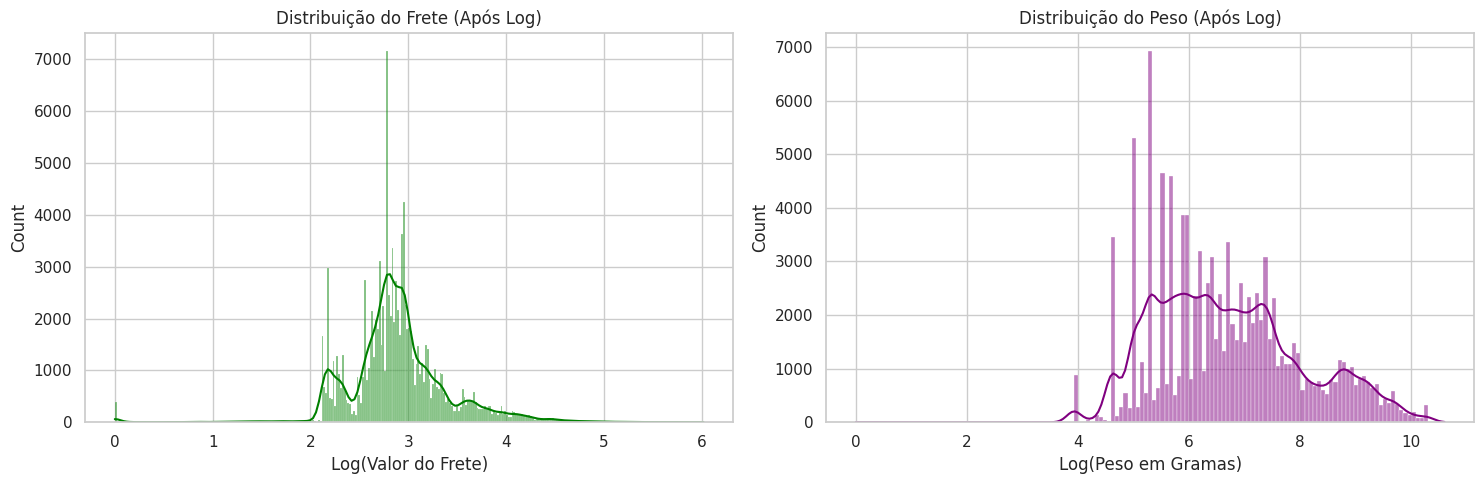

Verificação Pós-Processamento:
Total de valores nulos no dataset: 0
Novas colunas criadas (Exemplo de Estado): ['state_SP']


In [77]:
# Configurando o estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# 1. Comparativo do Valor do Frete (Antes vs Depois do Log)
plt.subplot(1, 2, 1)
sns.histplot(df_proc['log_freight_value'], kde=True, color='green')
plt.title('Distribuição do Frete (Após Log)')
plt.xlabel('Log(Valor do Frete)')

# 2. Comparativo do Peso do Produto (Após Log e Imputação de Nulos)
plt.subplot(1, 2, 2)
sns.histplot(df_proc['log_product_weight'], kde=True, color='purple')
plt.title('Distribuição do Peso (Após Log)')
plt.xlabel('Log(Peso em Gramas)')

plt.tight_layout()
plt.show()

# 3. Verificação Final de Nulos e Tipos
print("Verificação Pós-Processamento:")
print(f"Total de valores nulos no dataset: {df_proc[['log_freight_value', 'log_product_weight', 'target']].isnull().sum().sum()}")
print(f"Novas colunas criadas (Exemplo de Estado): {[col for col in df_proc.columns if 'state_SP' in col]}")

## Avaliação do Impacto do Pré-processamento: Comparação Antes e Depois das Transformações

Com o objetivo de validar a efetividade das técnicas de pré-processamento aplicadas, foi realizada uma análise comparativa das variáveis de frete e peso antes e após as transformações. Essa abordagem permite avaliar visualmente e quantitativamente o impacto das operações realizadas, como a imputação de valores ausentes e a aplicação de transformação logarítmica.

Foram analisadas as distribuições originais das variáveis e, em seguida, suas versões transformadas, possibilitando observar mudanças na dispersão, assimetria e presença de outliers. Além disso, foi utilizada a métrica de skewness (assimetria) para quantificar o grau de distorção das distribuições, fornecendo uma evidência objetiva da melhoria na qualidade dos dados.

## Avaliação das Transformações Aplicadas

A análise comparativa das variáveis de frete e peso antes e após o pré-processamento evidencia melhorias significativas na qualidade dos dados. Observa-se que, em sua forma original, ambas as variáveis apresentavam distribuições altamente assimétricas, com forte concentração em valores baixos e presença de caudas longas, indicando a existência de outliers relevantes.

Após a aplicação da transformação logarítmica, verifica-se uma redistribuição mais equilibrada dos valores, com redução da influência dos extremos e maior dispersão ao longo da escala. No caso do peso, além da transformação logarítmica, a imputação de valores ausentes pela mediana contribuiu para a estabilização da variável.

A métrica de skewness reforça essa melhoria, apresentando uma redução de 5.64 para -0.02 na variável de frete, indicando a transição de uma distribuição altamente assimétrica para uma distribuição aproximadamente simétrica. Esse resultado confirma a efetividade das transformações aplicadas, tornando os dados mais adequados para análises posteriores.



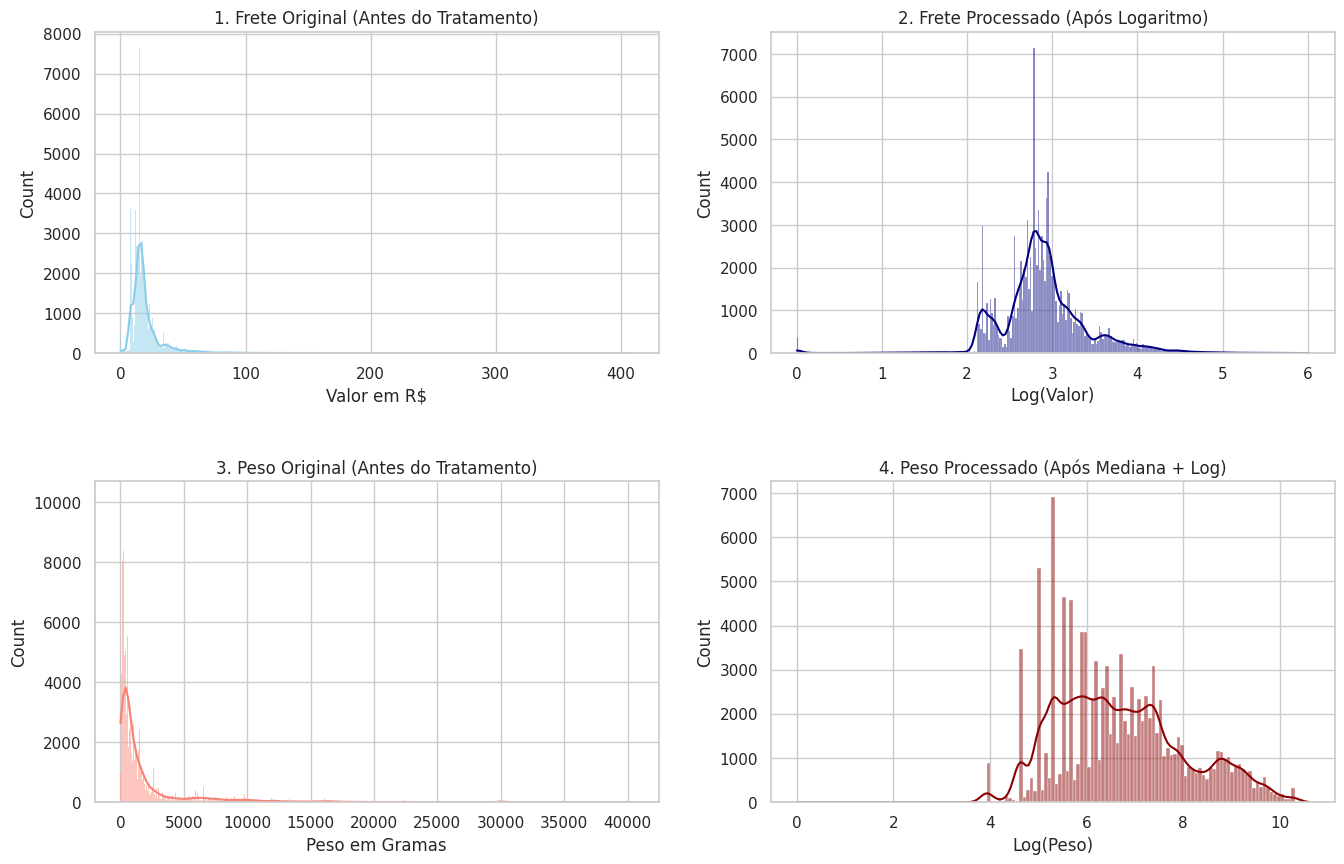

Skewness (Assimetria) do Frete ANTES: 5.64
Skewness (Assimetria) do Frete DEPOIS: -0.02


In [78]:
# Configurando a área de plotagem (2 linhas e 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plt.subplots_adjust(hspace=0.4)

# --- 1. FRETE: ANTES (Original com Outliers) ---
sns.histplot(df['freight_value'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Frete Original (Antes do Tratamento)')
axes[0, 0].set_xlabel('Valor em R$')

# --- 2. FRETE: DEPOIS (Log-Transformed) ---
sns.histplot(df_proc['log_freight_value'], kde=True, ax=axes[0, 1], color='navy')
axes[0, 1].set_title('2. Frete Processado (Após Logaritmo)')
axes[0, 1].set_xlabel('Log(Valor)')

# --- 3. PESO: ANTES (Original com Nulos) ---
sns.histplot(df['product_weight_g'].dropna(), kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('3. Peso Original (Antes do Tratamento)')
axes[1, 0].set_xlabel('Peso em Gramas')

# --- 4. PESO: DEPOIS (Após Imputação e Log) ---
sns.histplot(df_proc['log_product_weight'], kde=True, ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('4. Peso Processado (Após Mediana + Log)')
axes[1, 1].set_xlabel('Log(Peso)')

plt.show()

# Resumo numérico para o relatório
print(f"Skewness (Assimetria) do Frete ANTES: {df['freight_value'].skew():.2f}")
print(f"Skewness (Assimetria) do Frete DEPOIS: {df_proc['log_freight_value'].skew():.2f}")

## Conclusão

Este trabalho teve como objetivo analisar os fatores associados ao atraso na entrega de pedidos em um contexto de e-commerce, utilizando o dataset público da Olist. A partir de uma abordagem estruturada, foram conduzidas etapas de definição do problema, análise exploratória, pré-processamento e seleção de variáveis, permitindo uma compreensão abrangente do fenômeno estudado.

A análise exploratória revelou que o dataset apresenta características típicas de dados reais de negócio, como alta assimetria, presença de outliers e heterogeneidade entre produtos e regiões. Observou-se que variáveis como frete e peso possuem grande variabilidade, enquanto a distribuição de atrasos apresenta desbalanceamento, com predominância de pedidos entregues no prazo.

A partir das visualizações e análises combinadas, foi possível identificar que o atraso não ocorre de maneira uniforme, mas varia de acordo com fatores como localização geográfica, categoria de produto e período de compra. Em especial, a análise temporal indicou que o volume de pedidos pode impactar o desempenho logístico em determinados períodos, enquanto a análise por categoria evidenciou que diferentes tipos de produtos apresentam comportamentos distintos em relação ao atraso.

Na etapa de pré-processamento, foram aplicadas boas práticas de tratamento de dados, incluindo remoção de registros inconsistentes, imputação de valores faltantes e transformação logarítmica de variáveis assimétricas. Essas operações resultaram em uma melhora significativa na qualidade dos dados, comprovada tanto visualmente quanto por métricas estatísticas, como a redução da assimetria (skewness).

A seleção de variáveis foi realizada de forma criteriosa, considerando apenas informações disponíveis no momento do checkout, evitando assim o problema de data leakage. O conjunto final de atributos foi estruturado de modo a representar diferentes dimensões do problema, incluindo aspectos logísticos, físicos e geográficos, garantindo maior aderência a um cenário real de aplicação.

De forma geral, os resultados indicam que o atraso nas entregas é um fenômeno multifatorial, que não pode ser explicado por uma única variável isolada, mas sim pela interação entre diversos fatores. Essa característica reforça a importância de abordagens analíticas robustas e bem estruturadas para compreender problemas complexos em ambientes reais.

Por fim, o trabalho demonstra a relevância da aplicação de boas práticas em análise de dados, desde a compreensão do problema até a preparação adequada do dataset. A metodologia adotada contribui não apenas para a análise do caso específico, mas também como referência para estudos futuros que envolvam dados operacionais e problemas logísticos em larga escala.